In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from utils import *
from llm import llm_call

In [6]:
dev_nn = load_json('bert_neighbors_86/dev_nearest_examples.json')
dev_data = load_json('data/source/mrbench_v3_devset.json')

In [5]:
dev_nn[0]

{'dev_id': '221-362eb11a-f190-42a6-b2a4-985fafdcfa9eSEPSonnet',
 'dev_text': "Great, you've correctly identified the cost of the meat, now let's focus on calculating the total cost of meat for all the sandwiches needed.",
 'nearest_examples': [{'id': '221-362eb11a-f190-42a6-b2a4-985fafdcfa9eSEPSonnet',
   'original_index': 0,
   'label': 'Sonnet',
   'text': "Great, you've correctly identified the cost of the meat, now let's focus on calculating the total cost of meat for all the sandwiches needed.",
   'distance': 1.0},
  {'id': '1531-0594284f-6fba-4de2-90d2-6bc046e19578SEPSonnet',
   'original_index': 426,
   'label': 'Sonnet',
   'text': "Great, so let's recalculate her pension based on those 10 years past the 20-year mark, keeping in mind she earns 5% per year during that time.",
   'distance': 0.959592878818512},
  {'id': '232-a53cdc95-d429-4503-95b8-a22ddec0a735SEPSonnet',
   'original_index': 1681,
   'label': 'Sonnet',
   'text': "Great, now let's double-check how many pencils 

In [8]:
dev_data[0]

{'conversation_id': '221-362eb11a-f190-42a6-b2a4-985fafdcfa9e',
 'conversation_history': 'Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is: Tyson decided to make muffaletta sandwiches for the big game.\xa0\xa0Each sandwich required 1 pound each of meat and cheese and would serve 4 people.\xa0\xa0There would be 20 people in total watching the game.\xa0\xa0The meat cost $7.00 per pound and the cheese cost $3.00 per pound.\xa0\xa0How much money would he spend on the meat and cheese to make enough sandwiches to serve 20 people?\xa0\n\xa0Student: To serve 20 people, Tyson needs to make 20/4 = 5 sandwiches.\nEach sandwich requires 1+1 = 2 pounds of meat and cheese.\nFor 5 sandwiches, he needs a total of 2 x 5 = 10 pounds of meat and cheese.\nThe cost of 10 pounds of meat is 10 x $7.00 = $70.\nThe cost of 10 pounds of cheese is 10 x $3.00 = $30.\nThe total cost of meat and cheese is $70 + $30 = $100.\n\xa0100\xa0\n\xa0Tutor: How many pounds o

In [21]:
def get_example_from_data(data, idx):
    # search data list for the example with the given index
    for example in data:
        if example['conversation_id'] == idx:
            return example

In [57]:
for e in dev_nn:
   e_id, e_tutor = e['dev_id'].split('SEP')
   #print(e_id, e_tutor)
   example = get_example_from_data(dev_data, e_id)
   tutor_response = example['tutor_responses'][e_tutor]['response']
   annotations = example['tutor_responses'][e_tutor]['annotation']
   #print(annotations['Mistake_Identification'])
   
   if annotations['Mistake_Location'] != 'To some extent':
      continue
   
   print(e_id, e_tutor)
   print(annotations['Actionability'])

   neighbors_annotations = {'Yes':0, 'No':0, 'To some extent':0}
   
   for n in e['nearest_examples'][1:]:# skip the example itself
      n_id, n_tutor = n['id'].split('SEP')
      n_example = get_example_from_data(dev_data, n_id)
      mistake_label = n_example['tutor_responses'][n_tutor]['annotation']['Actionability']
      neighbors_annotations[mistake_label] += 1
   print(neighbors_annotations)
   # print the key with max value
   max_key = max(neighbors_annotations, key=neighbors_annotations.get)
   print('>>> ',max_key)

   assert tutor_response == e['dev_text']
   #break

221-362eb11a-f190-42a6-b2a4-985fafdcfa9e Llama318B
To some extent
{'Yes': 8, 'No': 7, 'To some extent': 4}
>>>  Yes
221-362eb11a-f190-42a6-b2a4-985fafdcfa9e Gemini
To some extent
{'Yes': 13, 'No': 5, 'To some extent': 1}
>>>  Yes
4642-e2ccfa55-280b-421c-9245-25ff56e3f33e Llama31405B
To some extent
{'Yes': 17, 'No': 0, 'To some extent': 2}
>>>  Yes
2490-377791e8-3745-4eca-bea1-d07b6eb67afe Mistral
To some extent
{'Yes': 14, 'No': 1, 'To some extent': 4}
>>>  Yes
2490-377791e8-3745-4eca-bea1-d07b6eb67afe Llama318B
To some extent
{'Yes': 6, 'No': 11, 'To some extent': 2}
>>>  No
2490-377791e8-3745-4eca-bea1-d07b6eb67afe Expert
Yes
{'Yes': 19, 'No': 0, 'To some extent': 0}
>>>  Yes
3260-394d7d67-8e4d-4847-87bb-f792e382524f Mistral
To some extent
{'Yes': 13, 'No': 4, 'To some extent': 2}
>>>  Yes
3260-394d7d67-8e4d-4847-87bb-f792e382524f Llama31405B
To some extent
{'Yes': 15, 'No': 1, 'To some extent': 3}
>>>  Yes
3260-394d7d67-8e4d-4847-87bb-f792e382524f Expert
To some extent
{'Yes': 12, '

Accuracy: 0.6700
F1 Score (macro): 0.5304
F1 Score (weighted): 0.6367

Classification Report:
                precision    recall  f1-score   support

           Yes       0.67      0.87      0.75      1310
To some extent       0.42      0.12      0.18       369
            No       0.72      0.60      0.66       797

      accuracy                           0.67      2476
     macro avg       0.60      0.53      0.53      2476
  weighted avg       0.65      0.67      0.64      2476



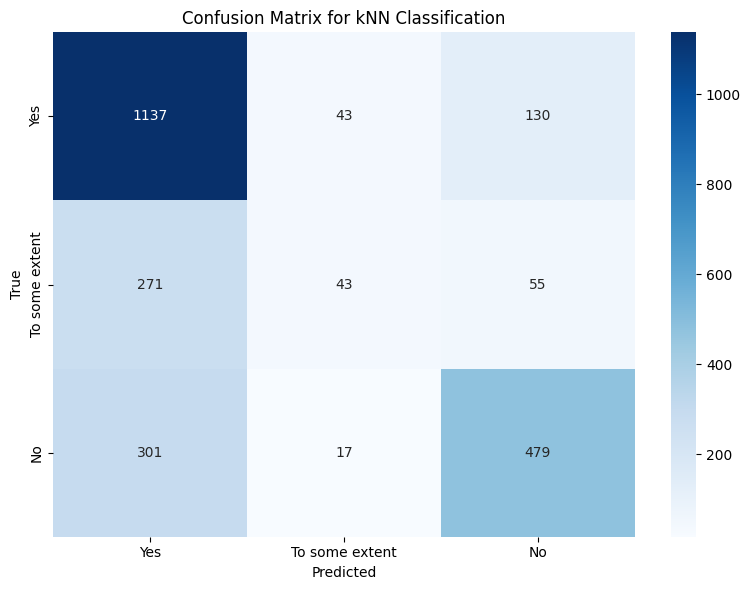

In [56]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Lists to store ground truth and predictions
y_true = []
y_pred = []

for e in dev_nn:
    e_id, e_tutor = e['dev_id'].split('SEP')
    example = get_example_from_data(dev_data, e_id)
    tutor_response = example['tutor_responses'][e_tutor]['response']
    annotations = example['tutor_responses'][e_tutor]['annotation']
    
    # Get ground truth
    ground_truth = annotations['Actionability']
    
    # Get kNN prediction
    neighbors_annotations = {'Yes': 0, 'No': 0, 'To some extent': 0}
    for n in e['nearest_examples'][1:]:  # skip the example itself
        n_id, n_tutor = n['id'].split('SEP')
        n_example = get_example_from_data(dev_data, n_id)
        mistake_label = n_example['tutor_responses'][n_tutor]['annotation']['Actionability']
        neighbors_annotations[mistake_label] += 1
    
    # Get prediction (key with max value)
    prediction = max(neighbors_annotations, key=neighbors_annotations.get)
    
    # Store for metrics calculation
    y_true.append(ground_truth)
    y_pred.append(prediction)

# Define the class order
class_order = ['Yes', 'To some extent', 'No']

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
# For multi-class F1, specify averaging method
f1_macro = f1_score(y_true, y_pred, average='macro', labels=class_order)
f1_weighted = f1_score(y_true, y_pred, average='weighted', labels=class_order)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# Detailed classification report with specific class order
print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=class_order))

# Create confusion matrix with specific class order
cm = confusion_matrix(y_true, y_pred, labels=class_order)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_order,
            yticklabels=class_order)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for kNN Classification')
plt.tight_layout()
plt.show()


=== Evaluating normalized_average weighting strategy ===
Accuracy: 0.4778
F1 Score (macro): 0.4439
F1 Score (weighted): 0.4982

Classification Report:
Class           Precision  Recall     F1-score   Support   
-------------------------------------------------------
Yes             0.67       0.46       0.54       1310.0
To some extent  0.19       0.36       0.25       369.0
No              0.52       0.56       0.54       797.0
accuracy                              0.48       2476.0


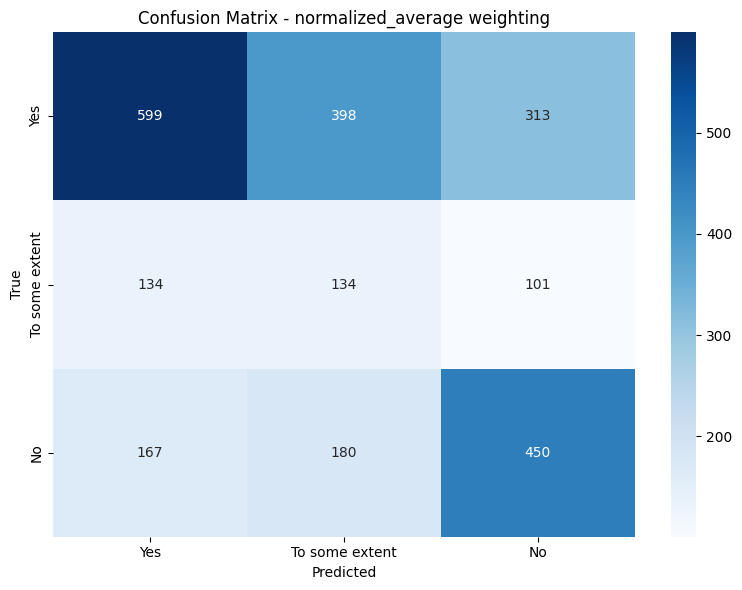


=== Evaluating rank_weighted weighting strategy ===
Accuracy: 0.6753
F1 Score (macro): 0.5699
F1 Score (weighted): 0.6590

Classification Report:
Class           Precision  Recall     F1-score   Support   
-------------------------------------------------------
Yes             0.70       0.81       0.75       1310.0
To some extent  0.38       0.21       0.27       369.0
No              0.72       0.66       0.69       797.0
accuracy                              0.68       2476.0


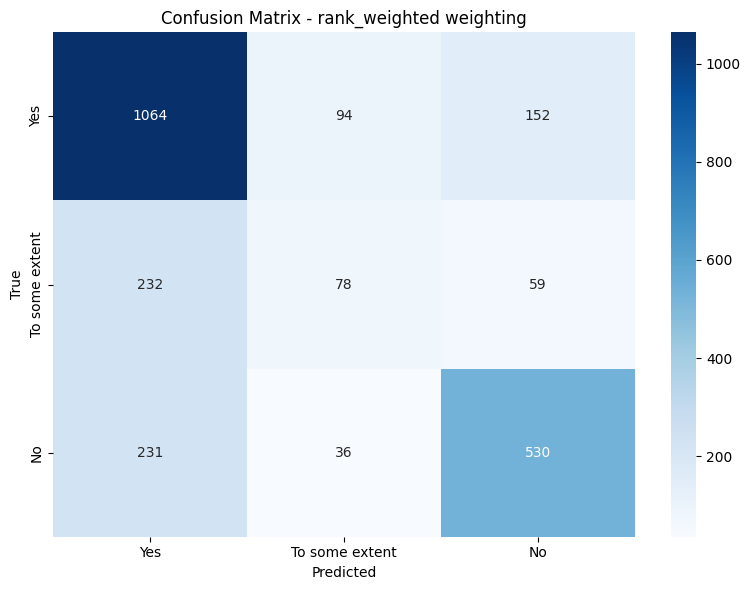


=== Evaluating inverse_distance weighting strategy ===
Accuracy: 0.6660
F1 Score (macro): 0.5346
F1 Score (weighted): 0.6374

Classification Report:
Class           Precision  Recall     F1-score   Support   
-------------------------------------------------------
Yes             0.67       0.84       0.75       1310.0
To some extent  0.38       0.13       0.19       369.0
No              0.72       0.62       0.66       797.0
accuracy                              0.67       2476.0


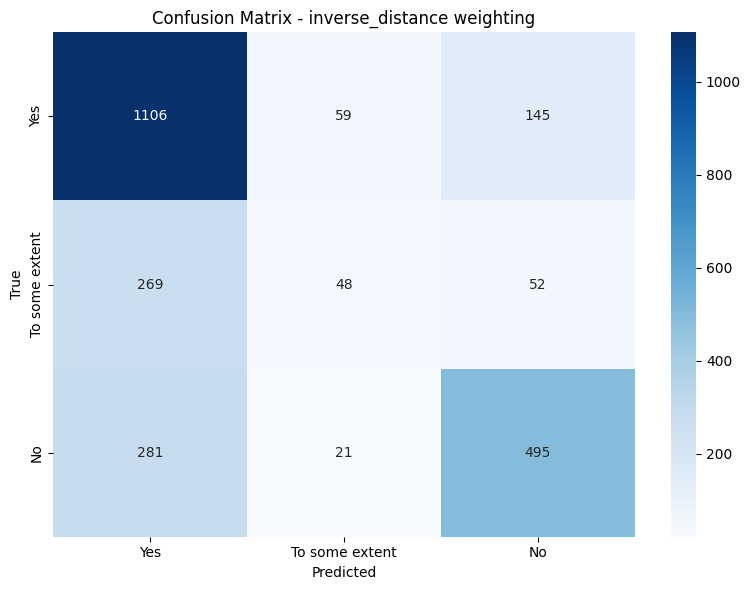


=== Evaluating confidence_adjusted weighting strategy ===
Accuracy: 0.6672
F1 Score (macro): 0.5338
F1 Score (weighted): 0.6373

Classification Report:
Class           Precision  Recall     F1-score   Support   
-------------------------------------------------------
Yes             0.67       0.85       0.75       1310.0
To some extent  0.39       0.13       0.19       369.0
No              0.71       0.62       0.66       797.0
accuracy                              0.67       2476.0


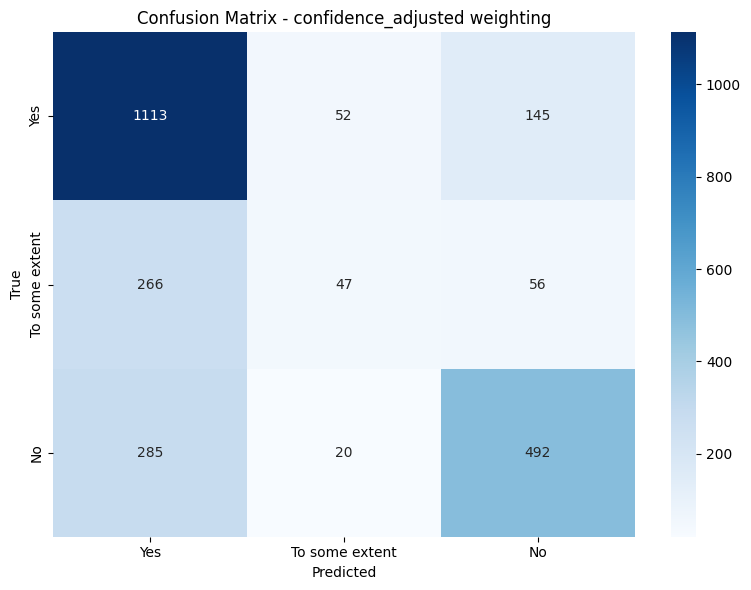


=== Best strategy: rank_weighted with F1-macro: 0.5699 ===

F1-scores for 'To some extent' class:
normalized_average: 0.2479
rank_weighted: 0.2704
inverse_distance: 0.1932
confidence_adjusted: 0.1926


In [58]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import defaultdict

def distance_weighted_knn(dev_nn, dev_data, class_order=['Yes', 'To some extent', 'No'], 
                          weighting_strategy='normalized_average'):
    """
    Perform distance-weighted kNN classification with various weighting strategies.
    
    Args:
        dev_nn: List of nearest neighbor results for dev examples
        dev_data: Original development data
        class_order: Order of classes for reporting
        weighting_strategy: Strategy for weighting votes ('normalized_average',
                           'rank_weighted', or 'inverse_distance')
    
    Returns:
        Dictionary with classification metrics
    """
    # Lists to store ground truth and predictions
    y_true = []
    y_pred = []
    
    for e in dev_nn:
        e_id, e_tutor = e['dev_id'].split('SEP')
        example = get_example_from_data(dev_data, e_id)
        annotations = example['tutor_responses'][e_tutor]['annotation']
        
        # Get ground truth
        ground_truth = annotations['Actionability']
        
        # Skip if no ground truth (uncomment if needed)
        # if ground_truth != 'No':
        #     continue
        
        # Prepare for kNN voting with weighted distances
        class_weights = defaultdict(list)
        class_counts = defaultdict(int)
        
        # Get neighbors and their distances
        neighbors = e['nearest_examples'][1:]  # Skip the example itself
        distances = [n['distance'] for n in neighbors]
        
        # Process each neighbor
        for neighbor, distance in zip(neighbors, distances):
            n_id, n_tutor = neighbor['id'].split('SEP')
            n_example = get_example_from_data(dev_data, n_id)
            label = n_example['tutor_responses'][n_tutor]['annotation']['Actionability']
            
            # Store distance for this class
            class_weights[label].append(distance)
            class_counts[label] += 1
        
        # Calculate weighted scores based on chosen strategy
        class_scores = {}
        
        if weighting_strategy == 'normalized_average':
            # Average similarity within each class (higher is better)
            for label, distances in class_weights.items():
                if distances:  # Check if list is not empty
                    class_scores[label] = sum(distances) / len(distances)
                else:
                    class_scores[label] = 0
        
        elif weighting_strategy == 'rank_weighted':
            # Weight by rank (closer neighbors have more influence)
            sorted_pairs = [(neighbor['id'], neighbor['distance']) 
                           for neighbor in sorted(neighbors, key=lambda x: x['distance'], reverse=True)]
            
            for rank, (n_id, distance) in enumerate(sorted_pairs):
                n_id, n_tutor = n_id.split('SEP')
                n_example = get_example_from_data(dev_data, n_id)
                label = n_example['tutor_responses'][n_tutor]['annotation']['Actionability']
                
                # Rank weight (decreasing with rank)
                weight = 1.0 / (rank + 1)
                
                if label in class_scores:
                    class_scores[label] += weight
                else:
                    class_scores[label] = weight
        
        elif weighting_strategy == 'inverse_distance':
            # Weight by inverse of (1-similarity) - prevents division by zero
            for label, distances in class_weights.items():
                if distances:
                    # For cosine similarity where 1.0 is perfect match
                    weights = [1.0 / (1.001 - d) for d in distances]
                    class_scores[label] = sum(weights)
                else:
                    class_scores[label] = 0
                    
        elif weighting_strategy == 'confidence_adjusted':
            # Adjust by confidence (variance of similarities within class)
            for label, distances in class_weights.items():
                if len(distances) > 1:
                    mean_dist = np.mean(distances)
                    # Lower variance = higher confidence
                    variance = np.var(distances)
                    confidence = 1.0 / (1.0 + variance)
                    class_scores[label] = mean_dist * confidence * len(distances)
                elif len(distances) == 1:
                    # Single neighbor case
                    class_scores[label] = distances[0]
                else:
                    class_scores[label] = 0
        
        # Get prediction (class with highest score)
        if class_scores:
            prediction = max(class_scores, key=class_scores.get)
        else:
            prediction = "No"  # Default if no neighbors found
        
        # Store for metrics calculation
        y_true.append(ground_truth)
        y_pred.append(prediction)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', labels=class_order)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', labels=class_order)
    
    # Prepare classification report
    report = classification_report(y_true, y_pred, labels=class_order, output_dict=True)
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=class_order)
    
    # Return all metrics
    results = {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'classification_report': report,
        'confusion_matrix': cm,
        'y_true': y_true,
        'y_pred': y_pred
    }
    
    return results

# Run and evaluate different weighting strategies
strategies = [
    'normalized_average',
    'rank_weighted',
    'inverse_distance',
    'confidence_adjusted'
]

results = {}

for strategy in strategies:
    print(f"\n=== Evaluating {strategy} weighting strategy ===")
    results[strategy] = distance_weighted_knn(dev_nn, dev_data, weighting_strategy=strategy)
    
    # Print metrics
    print(f"Accuracy: {results[strategy]['accuracy']:.4f}")
    print(f"F1 Score (macro): {results[strategy]['f1_macro']:.4f}")
    print(f"F1 Score (weighted): {results[strategy]['f1_weighted']:.4f}")
    
    # Print classification report
    report = results[strategy]['classification_report']
    print("\nClassification Report:")
    print(f"{'Class':<15} {'Precision':<10} {'Recall':<10} {'F1-score':<10} {'Support':<10}")
    print("-" * 55)
    
    for label in ['Yes', 'To some extent', 'No']:
        if label in report:
            print(f"{label:<15} {report[label]['precision']:.2f}       "
                  f"{report[label]['recall']:.2f}       "
                  f"{report[label]['f1-score']:.2f}       "
                  f"{report[label]['support']}")
    
    print(f"{'accuracy':<15}                       {report['accuracy']:.2f}       "
          f"{sum([report[l]['support'] for l in ['Yes', 'To some extent', 'No']])}")
    
    # Plot confusion matrix
    cm = results[strategy]['confusion_matrix']
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Yes', 'To some extent', 'No'],
                yticklabels=['Yes', 'To some extent', 'No'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {strategy} weighting')
    plt.tight_layout()
    plt.show()

# Identify best strategy
best_strategy = max(strategies, key=lambda s: results[s]['f1_macro'])
print(f"\n=== Best strategy: {best_strategy} with F1-macro: {results[best_strategy]['f1_macro']:.4f} ===")

# Additional analysis for the "To some extent" class
to_some_extent_f1 = {
    strategy: results[strategy]['classification_report']['To some extent']['f1-score']
    for strategy in strategies
}

print("\nF1-scores for 'To some extent' class:")
for strategy, f1 in to_some_extent_f1.items():
    print(f"{strategy}: {f1:.4f}")